2026-03-30 17:57:30.208871: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774893450.234035     215 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774893450.242370     215 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774893450.264407     215 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774893450.264430     215 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774893450.264433     215 computation_placer.cc:177] computation placer alr

Using device: cuda
Epoch 1/10 | F1: 0.8321 | Acc: 0.7982
✅ Best model saved!
Epoch 2/10 | F1: 0.8321 | Acc: 0.7982
Epoch 3/10 | F1: 0.8833 | Acc: 0.8772
✅ Best model saved!
Epoch 4/10 | F1: 0.8889 | Acc: 0.8772
✅ Best model saved!
Epoch 5/10 | F1: 0.8317 | Acc: 0.8509
Epoch 6/10 | F1: 0.8750 | Acc: 0.8772
Epoch 7/10 | F1: 0.9310 | Acc: 0.9298
✅ Best model saved!
Epoch 8/10 | F1: 0.9310 | Acc: 0.9298
Epoch 9/10 | F1: 0.9231 | Acc: 0.9211
Epoch 10/10 | F1: 0.9310 | Acc: 0.9298


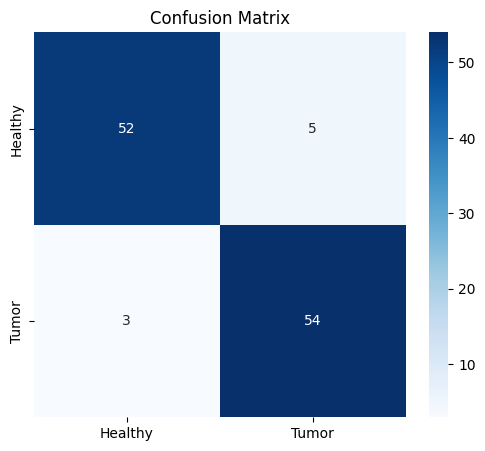

              precision    recall  f1-score   support

     Healthy       0.95      0.91      0.93        57
       Tumor       0.92      0.95      0.93        57

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114

ROC-AUC: 0.9705


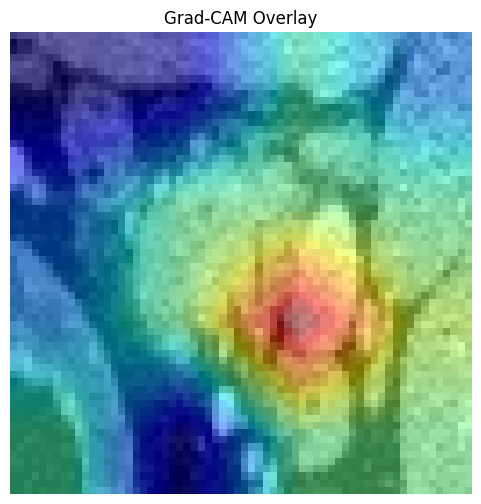

In [1]:
# ================= INSTALL =================
!pip install monai timm nibabel -q

# ================= IMPORTS =================
import os
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F  # Added for Grad-CAM
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ---------------- MONAI IMPORTS ----------------
from monai.networks.nets import resnet
from monai.transforms import (
    Compose,
    LoadImage,
    EnsureChannelFirst,  # Replacement for the removed AddChannel
    ScaleIntensity,
    RandRotate90,
    RandFlip
)
from monai.data import decollate_batch

# ================= CONFIG =================
BASE_PATH = "/kaggle/input/datasets/rksrank1/pancreatic-cancer/Task07_Pancreas"
IMAGE_DIR = os.path.join(BASE_PATH, "imagesTr")
MASK_DIR = os.path.join(BASE_PATH, "labelsTr")

PATCH_SIZE = 64
BATCH_SIZE = 4
EPOCHS = 10
LR = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# ================= DATASET =================
class Pancreas3DDataset(Dataset):
    def __init__(self, files, patch_size=PATCH_SIZE):
        self.files = files
        self.patch_size = patch_size
        self.samples = self._prepare_samples()

    def _prepare_samples(self):
        samples = []
        for file in self.files:
            if file.startswith("._"): 
                continue
            mask_path = os.path.join(MASK_DIR, file)
            if not os.path.exists(mask_path): 
                continue

            mask_vol = nib.load(mask_path).get_fdata()
            tumor_indices = np.argwhere(mask_vol == 2)

            if len(tumor_indices) > 0:
                # Tumor sample
                rand_idx = np.random.randint(len(tumor_indices))
                samples.append((file, tumor_indices[rand_idx], 1))
                
                # Balanced healthy sample
                h, w, d = mask_vol.shape
                for _ in range(50): 
                    rp = [np.random.randint(0,h), np.random.randint(0,w), np.random.randint(0,d)]
                    if mask_vol[tuple(rp)] == 0:
                        samples.append((file, rp, 0))
                        break
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file, center, label = self.samples[idx]
        img_vol = nib.load(os.path.join(IMAGE_DIR, file)).get_fdata()
        z, y, x = [int(c) for c in center]

        # Extract 3D Patch
        z_s, y_s, x_s = max(0, z-PATCH_SIZE//2), max(0, y-PATCH_SIZE//2), max(0, x-PATCH_SIZE//2)
        patch = img_vol[z_s:z_s+PATCH_SIZE, y_s:y_s+PATCH_SIZE, x_s:x_s+PATCH_SIZE]

        # Pad if necessary
        if patch.shape != (PATCH_SIZE, PATCH_SIZE, PATCH_SIZE):
            patch = np.pad(patch, [(0, PATCH_SIZE - patch.shape[0]),
                                   (0, PATCH_SIZE - patch.shape[1]),
                                   (0, PATCH_SIZE - patch.shape[2])], mode='constant')

        # Normalize CT intensity
        patch = np.clip(patch, -100, 200)
        patch = (patch + 100) / 300.0

        # Add channel dimension
        return torch.tensor(patch[np.newaxis,...], dtype=torch.float32), torch.tensor(label, dtype=torch.long)

# ================= DATA LOADERS =================
all_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith((".nii", ".nii.gz")) and not f.startswith(".")])
train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)

train_dataset = Pancreas3DDataset(train_files)
val_dataset = Pancreas3DDataset(val_files)

# Compute weights for balanced sampler
train_labels = [l.item() for _, l in train_dataset]
class_counts = np.bincount(train_labels)
class_weights = [sum(class_counts)/c for c in class_counts]
weights = [class_weights[l] for l in train_labels]
sampler = WeightedRandomSampler(weights, len(weights))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ================= MODEL =================
class ResNet3DClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # MONAI ResNet3D: Corrected n_classes to num_classes
        self.backbone = resnet.resnet50(
            spatial_dims=3, 
            n_input_channels=1, 
            num_classes=2, 
            pretrained=False
        )
    
    def forward(self, x):
        return self.backbone(x)

model = ResNet3DClassifier().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ================= TRAIN =================
best_f1 = 0
for epoch in range(EPOCHS):
    model.train()
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
    scheduler.step()

    # Validation
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            preds.extend(out.argmax(1).cpu().numpy())
            gts.extend(labels.cpu().numpy())

    f1 = f1_score(gts, preds)
    acc = accuracy_score(gts, preds)
    print(f"Epoch {epoch+1}/{EPOCHS} | F1: {f1:.4f} | Acc: {acc:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_3d_resnet.pth")
        print("✅ Best model saved!")

# ================= EVALUATION =================
all_preds, all_labels, all_probs = [], [], []

model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)[:,1].cpu().numpy()
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy','Tumor'], yticklabels=['Healthy','Tumor'])
plt.title("Confusion Matrix")
plt.show()

# Classification report
print(classification_report(all_labels, all_preds, target_names=['Healthy','Tumor']))

# ROC-AUC
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
print(f"ROC-AUC: {roc_auc:.4f}")

# ================= 3D Grad-CAM =================
class GradCAM3D:
    def __init__(self, model):
        self.model = model
        self.model.eval()
        self.gradients = None
        self.activations = None

        # Hook last conv layer for ResNet50 3D
        last_conv = self.model.backbone.layer4[2].conv3 
        last_conv.register_forward_hook(self.forward_hook)
        last_conv.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output.detach()

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x, class_idx=None):
        x = x.unsqueeze(0).to(next(self.model.parameters()).device)
        output = self.model(x)
        if class_idx is None:
            class_idx = output.argmax(1).item()
        self.model.zero_grad()
        loss = output[0, class_idx]
        loss.backward()

        weights = self.gradients.mean(dim=(2,3,4), keepdim=True)
        cam = F.relu((weights * self.activations).sum(1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[2:], mode='trilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

def show_cam_on_slice(cam, img, slice_idx=None):
    if slice_idx is None:
        slice_idx = img.shape[0]//2
    plt.figure(figsize=(6,6))
    plt.imshow(img[slice_idx], cmap='gray')
    plt.imshow(cam[slice_idx], cmap='jet', alpha=0.5)
    plt.title("Grad-CAM Overlay")
    plt.axis('off')
    plt.show()

# Generate Grad-CAM for the first validation sample
# (Ensure val_loader has at least one batch)
imgs, labels = next(iter(val_loader))
img = imgs[0]
gradcam = GradCAM3D(model)
cam = gradcam(img)
show_cam_on_slice(cam, img[0].cpu().numpy())